In [1]:
# General imports 
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats 
import os 
import re
import pandas as pd
from skimage import measure
from pathlib import Path

# Pynwb imports
from hdmf_zarr import NWBZarrIO
from nwbwidgets import nwb2widget

In [2]:
# Load csv as a Pandas DataFrame 
metadata = pd.read_csv('/data/metadata.csv', index_col = False) 

# Sort values by name and reindex 
metadata = metadata.sort_values(by = ['name']).reset_index(drop = True)
metadata.head()

,_id,name,subject_id,session_time,session_type,genotype,virus_injection_materials,ophys_fov,session_number
0,4fcfc173-452d-4d5b-b441-7b26da3d781b,single-plane-ophys_731015_2025-01-24_20-00-44_...,731015,2025-01-24T18:41:22.550000-08:00,BCI single neuron stim,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,FOV_04,20.0
1,1f1039a9-72a2-4dd0-880b-2fe06c64e96a,single-plane-ophys_731015_2025-01-28_17-40-57_...,731015,2025-01-28T17:40:57.996000-08:00,BCI single neuron stim,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,FOV_04,22.0
2,b46c42e9-b7cc-4a1e-832d-9721816c9bc5,single-plane-ophys_731015_2025-01-28_18-56-35_...,731015,2025-01-28T17:40:57.996000-08:00,BCI single neuron stim,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,FOV_04,22.0
3,b2497fb0-0e67-4c9a-b543-76ccc2c7fdbd,single-plane-ophys_731015_2025-01-31_20-37-19_...,731015,2025-01-31T20:37:19.623000-08:00,BCI single neuron stim,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,FOV_04,23.0
4,069e10c0-6d10-4101-bc33-f3febf0a6565,single-plane-ophys_740369_2025-01-09_17-18-37_...,740369,2025-01-09T16:01:04.455000-08:00,BCI single neuron stim,Slc17a6-IRES-Cre/wt;Ai230(TIT2L-XCaMPG-WPRE-IC...,pAAV-hSyn1-RiboL1-GCaMP8s-WPRE,FOV_05,22.0


In [3]:
idx = 10

subject_id = metadata.subject_id[idx] 
date = metadata.session_time[idx][0:10] # save just the year, month, and date

In [4]:
# to do - simplify this loading function 
def load_nwb(subject_id, date):
    """
    Searches the /data directory for a folder and subfolder containing the subject_id and date,
    and loads the corresponding NWB file.

    Parameters:
    - subject_id (str): Subject identifier to search for in directory names
    - date (str): Date string (e.g. '2023-05-09') to search for in directory names

    Returns:
    - nwbfile: Loaded NWBFile object if found, else None
    """

    # Create pattern for matching
    pattern = rf".*{subject_id}.*{date}.*"
    base_path = Path('/data')
    
    # Find matching first-level directories
    first_matches = [d for d in base_path.iterdir() 
                     if d.is_dir() and re.search(pattern, d.name)]
    
    if not first_matches:
        print(f"Directory matching subject_id={subject_id} and date={date} not found in /data.")
        return None
    
    first_dir = first_matches[0]
    print(f"Found first-level directory: {first_dir.name}")
    
    # Find matching second-level directories
    second_matches = [d for d in first_dir.iterdir() 
                      if d.is_dir() and re.search(pattern, d.name)]
    
    if not second_matches:
        print(f"No second-level directory matching subject_id={subject_id} and date={date} found.")
        return None
    
    nwb_path = second_matches[0]
    print(f"Found second-level directory: {nwb_path.name}")
    
    # Check if path exists and load NWB file
    try:
        with NWBZarrIO(str(nwb_path), 'r') as io:
            nwbfile = io.read()
            print('Loaded NWB file from:', nwb_path)
            return nwbfile
    except Exception as e:
        print(f'Error loading file from {nwb_path}: {e}')
        return None

In [5]:
nwbfile = load_nwb(subject_id, date)

Found first-level directory: single-plane-ophys_767715_2025-01-31_18-15-21_processed_2025-07-23_12-21-52
Found second-level directory: single-plane-ophys_767715_2025-01-31_18-15-21_behavior_nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Loaded NWB file from: /data/single-plane-ophys_767715_2025-01-31_18-15-21_processed_2025-07-23_12-21-52/single-plane-ophys_767715_2025-01-31_18-15-21_behavior_nwb


In [7]:
dff = nwbfile.processing["processed"].data_interfaces["dff"].roi_response_series["dff"].data
photostim = nwbfile.stimulus["PhotostimTrials"].to_dataframe()

In [ ]:
# How does connection strength depend on distance? 

In [23]:
# Create a 3D array of photostimulus-aligned responses across trials: Fstim(time, neurons, trials) 

#Initialize variables 
plt.figure(figsize=(10,3))
# Define frame window bins 
pre_frames = 30
post_frames = 30
window_size = pre_frames + post_frames

# Reshape dff into a time window x neuron x trial ndarray 
stim_frames = photostim[photostim.stimulus_name == 'photostim']['start_frame'].values 
n_trials = len(stim_frames)
n_neurons = dff.shape[1]
Fstim = np.full((window_size, n_neurons, n_trials), np.nan)

for k, frame in enumerate(stim_frames):
    if frame - pre_frames < 0 or frame + post_frames >= dff.shape[0]:
        continue
    Fstim[:, :, k] = dff[frame - pre_frames : frame + post_frames, :]
print(f'Fstim shape:{Fstim.shape}')

Fstim shape:(60, 2243, 1022)


<Figure size 1000x300 with 0 Axes>

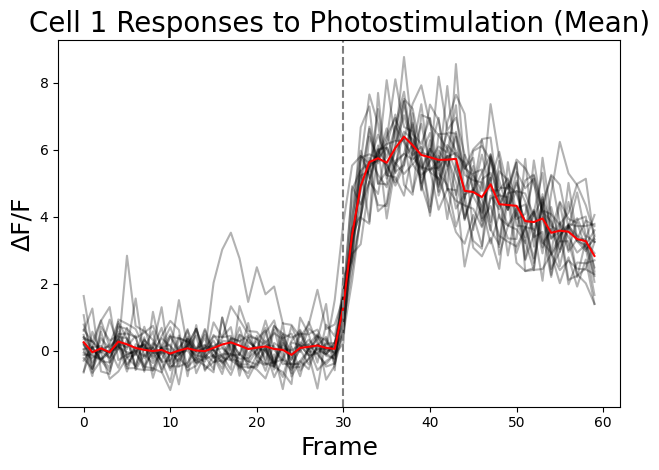

In [34]:
cell = 1
# Get the photostimulated cell order  
seq = photostim[photostim.stimulus_name == 'photostim']['closest_roi'].values

# Filter Fstim only for trials where targeted neuron was targeted 
trials = np.where(seq == cell)[0]
# Plot single trial responses 
plt.plot(Fstim[:, cell, trials], 'k', alpha=0.3)
# Plot mean photostimulation response
plt.plot(np.nanmean(Fstim[:, cell, trials], axis=1), 'r')
plt.axvline(pre_frames, color='gray', linestyle='--')
plt.title(f'Cell {cell} Responses to Photostimulation (Mean)', fontsize=20)
plt.xlabel('Frame', fontsize=18)
plt.ylabel('ΔF/F', fontsize=18)
plt.tight_layout()
plt.show()

/tmp/ipykernel_825/4237604857.py:9: RuntimeWarning: Mean of empty slice
  favg[:, :, gi] = np.nanmean(Fstim[:, :, ind], axis=2)
/tmp/ipykernel_825/4237604857.py:15: RuntimeWarning: Mean of empty slice
  f = np.nanmean(np.nanmean(favg, axis=2), axis=1)


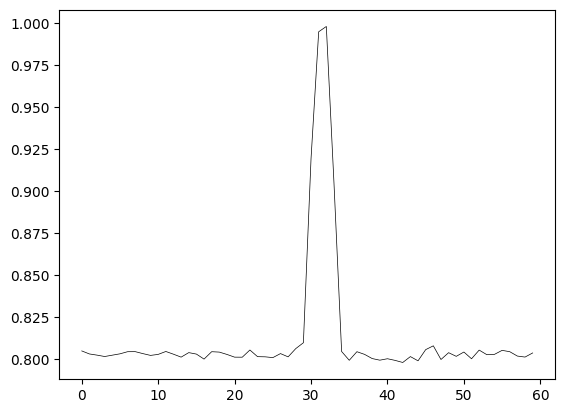

In [50]:
# Take the average of Fstim to get each neuron's average response to all photostim presentations 
seq = photostim[photostim.stimulus_name == 'photostim']['group_index'].values
numGroups = np.max(seq) 
seq = seq - 1 # Convert from Matlab to Python indexing 

favg = np.zeros((Fstim.shape[0], Fstim.shape[1], numGroups))
for gi in range(numGroups):
    ind = np.where(seq == gi)[0]
    favg[:, :, gi] = np.nanmean(Fstim[:, :, ind], axis=2)


favg_raw = favg.copy()
favg_raw.shape

f = np.nanmean(np.nanmean(favg, axis=2), axis=1)
plt.plot(f,'k',linewidth=.5)
# plt.ylim((-.05,.25))


# Remove light artifact 